# Advanced Multi-Source Data Pipeline

### CoinGecko API + Web Scraping → Data Cleaning → Exploratory Data Analysis

## 1. Project Introduction

### Problem Statement

In real-world applications, data is rarely available in a clean and analysis-ready format. Data analysts and data scientists often need to collect data from multiple heterogeneous sources such as APIs and websites.

This project develops an end-to-end data pipeline using two different data sources:

1. **CoinGecko API** — Cryptocurrency market data
2. **Books to Scrape** — Book product data collected through web scraping

The collected data will be inspected, cleaned, transformed, and analyzed to identify patterns, relationships, anomalies, and useful insights.

### Analytical Goal

The primary goal is to transform raw multi-source data into reliable, analysis-ready datasets and perform exploratory analysis to generate meaningful insights.

### Project Objectives

* Collect cryptocurrency market data from the CoinGecko API.
* Scrape book-product information from Books to Scrape.
* Identify and handle missing values.
* Remove duplicate and invalid records.
* Correct inconsistent data types and formats.
* Detect and analyze outliers.
* Create meaningful analytical features.
* Perform univariate, bivariate, and multivariate EDA.
* Perform statistical analysis where appropriate.
* Create static and interactive visualizations.
* Generate insights and recommendations.
* Develop reusable data-cleaning functions.
* Export the final cleaned datasets.


## 2. Import Libraries

In [2]:
import requests
import pandas as pd
import numpy as np

from bs4 import BeautifulSoup

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from scipy import stats
from sklearn.ensemble import IsolationForest

import missingno as msno

## 3. Data Collection

### 3.1 Books to Scrape Data Collection

In [3]:
books_url = "https://books.toscrape.com/"

In [4]:
response = requests.get(books_url)

print(response.status_code)

200


In [5]:
print(response.text[:1000])

<!DOCTYPE html>
<!--[if lt IE 7]>      <html lang="en-us" class="no-js lt-ie9 lt-ie8 lt-ie7"> <![endif]-->
<!--[if IE 7]>         <html lang="en-us" class="no-js lt-ie9 lt-ie8"> <![endif]-->
<!--[if IE 8]>         <html lang="en-us" class="no-js lt-ie9"> <![endif]-->
<!--[if gt IE 8]><!--> <html lang="en-us" class="no-js"> <!--<![endif]-->
    <head>
        <title>
    All products | Books to Scrape - Sandbox
</title>

        <meta http-equiv="content-type" content="text/html; charset=UTF-8" />
        <meta name="created" content="24th Jun 2016 09:29" />
        <meta name="description" content="" />
        <meta name="viewport" content="width=device-width" />
        <meta name="robots" content="NOARCHIVE,NOCACHE" />

        <!-- Le HTML5 shim, for IE6-8 support of HTML elements -->
        <!--[if lt IE 9]>
        <script src="//html5shim.googlecode.com/svn/trunk/html5.js"></script>
        <![endif]-->

        
            <link rel="shortcut icon" href="static/oscar/favicon.

In [6]:
soup = BeautifulSoup(response.text, "html.parser")

In [7]:
print(soup.title.text)


    All products | Books to Scrape - Sandbox



In [8]:
book = soup.find("article", class_="product_pod")

print(book.prettify()[:3000])

<article class="product_pod">
 <div class="image_container">
  <a href="catalogue/a-light-in-the-attic_1000/index.html">
   <img alt="A Light in the Attic" class="thumbnail" src="media/cache/2c/da/2cdad67c44b002e7ead0cc35693c0e8b.jpg"/>
  </a>
 </div>
 <p class="star-rating Three">
  <i class="icon-star">
  </i>
  <i class="icon-star">
  </i>
  <i class="icon-star">
  </i>
  <i class="icon-star">
  </i>
  <i class="icon-star">
  </i>
 </p>
 <h3>
  <a href="catalogue/a-light-in-the-attic_1000/index.html" title="A Light in the Attic">
   A Light in the ...
  </a>
 </h3>
 <div class="product_price">
  <p class="price_color">
   Â£51.77
  </p>
  <p class="instock availability">
   <i class="icon-ok">
   </i>
   In stock
  </p>
  <form>
   <button class="btn btn-primary btn-block" data-loading-text="Adding..." type="submit">
    Add to basket
   </button>
  </form>
 </div>
</article>



In [9]:
title = book.find("h3").find("a")["title"]

print(title)

A Light in the Attic


In [10]:
response.encoding = response.apparent_encoding

In [11]:
soup = BeautifulSoup(response.text, "html.parser")

In [12]:
book = soup.find("article", class_="product_pod")

price = book.find("p", class_="price_color").text

print(price)

£51.77


In [13]:
rating = book.find("p", class_="star-rating")["class"]

print(rating)

['star-rating', 'Three']


In [14]:
availability = book.find("p", class_="instock").get_text(strip=True)

print(availability)

In stock


In [15]:
books = soup.find_all("article", class_="product_pod")

print(len(books))

20


In [16]:
for book in books[:3]:
    title = book.find("h3").find("a")["title"]
    print(title)

A Light in the Attic
Tipping the Velvet
Soumission


In [17]:
book = books[0]

title = book.find("h3").find("a")["title"]

price = book.find("p", class_="price_color").get_text(strip=True)

rating = book.find("p", class_="star-rating")["class"][1]

availability = book.find("p", class_="instock").get_text(" ", strip=True)

book_url = book.find("h3").find("a")["href"]

print("Title:", title)
print("Price:", price)
print("Rating:", rating)
print("Availability:", availability)
print("URL:", book_url)

Title: A Light in the Attic
Price: £51.77
Rating: Three
Availability: In stock
URL: catalogue/a-light-in-the-attic_1000/index.html


In [18]:
books_data = []

for book in books:
    title = book.find("h3").find("a")["title"]
    price = book.find("p", class_="price_color").get_text(strip=True)
    rating = book.find("p", class_="star-rating")["class"][1]
    availability = book.find("p", class_="instock").get_text(" ", strip=True)
    book_url = book.find("h3").find("a")["href"]

    books_data.append({
        "title": title,
        "price": price,
        "rating": rating,
        "availability": availability,
        "book_url": book_url
    })

In [19]:
books_raw = pd.DataFrame(books_data)

In [20]:
print("Rows:", len(books_raw))
print("Columns:", len(books_raw.columns))

Rows: 20
Columns: 5


In [21]:
books_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   title         20 non-null     str  
 1   price         20 non-null     str  
 2   rating        20 non-null     str  
 3   availability  20 non-null     str  
 4   book_url      20 non-null     str  
dtypes: str(5)
memory usage: 932.0 bytes


In [22]:
next_button = soup.find("li", class_="next")

print(next_button)

<li class="next"><a href="catalogue/page-2.html">next</a></li>


In [23]:
from urllib.parse import urljoin

current_url = books_url
all_books = []

while current_url:
    response = requests.get(current_url)
    response.encoding = response.apparent_encoding
    
    soup = BeautifulSoup(response.text, "html.parser")
    
    books = soup.find_all("article", class_="product_pod")
    
    for book in books:
        title = book.find("h3").find("a")["title"]
        price = book.find("p", class_="price_color").get_text(strip=True)
        rating = book.find("p", class_="star-rating")["class"][1]
        availability = book.find(
            "p", class_="instock availability"
        ).get_text(" ", strip=True)
        
        book_url = urljoin(
            current_url,
            book.find("h3").find("a")["href"]
        )
        
        all_books.append({
            "title": title,
            "price": price,
            "rating": rating,
            "availability": availability,
            "book_url": book_url
        })
    
    next_button = soup.find("li", class_="next")
    
    if next_button:
        next_url = next_button.find("a")["href"]
        current_url = urljoin(current_url, next_url)
    else:
        current_url = None

print("Total books scraped:", len(all_books))

Total books scraped: 1000


In [24]:
books_raw = pd.DataFrame(all_books)

In [25]:
print(books_raw.shape)

(1000, 5)


In [26]:
books_raw.head()

,title,price,rating,availability,book_url
0,A Light in the Attic,£51.77,Three,In stock,https://books.toscrape.com/catalogue/a-light-i...
1,Tipping the Velvet,£53.74,One,In stock,https://books.toscrape.com/catalogue/tipping-t...
2,Soumission,£50.10,One,In stock,https://books.toscrape.com/catalogue/soumissio...
3,Sharp Objects,£47.82,Four,In stock,https://books.toscrape.com/catalogue/sharp-obj...
4,Sapiens: A Brief History of Humankind,£54.23,Five,In stock,https://books.toscrape.com/catalogue/sapiens-a...


In [27]:
books_raw.tail()

,title,price,rating,availability,book_url
995,Alice in Wonderland (Alice's Adventures in Won...,£55.53,One,In stock,https://books.toscrape.com/catalogue/alice-in-...
996,"Ajin: Demi-Human, Volume 1 (Ajin: Demi-Human #1)",£57.06,Four,In stock,https://books.toscrape.com/catalogue/ajin-demi...
997,A Spy's Devotion (The Regency Spies of London #1),£16.97,Five,In stock,https://books.toscrape.com/catalogue/a-spys-de...
998,1st to Die (Women's Murder Club #1),£53.98,One,In stock,https://books.toscrape.com/catalogue/1st-to-di...
999,"1,000 Places to See Before You Die",£26.08,Five,In stock,https://books.toscrape.com/catalogue/1000-plac...


In [28]:
books_raw.to_csv(
    "../data/raw/books_raw.csv",
    index=False
)

In [29]:
import os

print(os.path.exists("../data/raw/books_raw.csv"))

True


In [30]:
books_check = pd.read_csv("../data/raw/books_raw.csv")

print("Shape:", books_check.shape)
print("Columns:", books_check.columns.tolist())

Shape: (1000, 5)
Columns: ['title', 'price', 'rating', 'availability', 'book_url']


## 4. Initial Data Inspection

### 4.1 Books Dataset

In [31]:
print("Number of rows:", books_raw.shape[0])
print("Number of columns:", books_raw.shape[1])

Number of rows: 1000
Number of columns: 5


In [32]:
books_raw.columns

Index(['title', 'price', 'rating', 'availability', 'book_url'], dtype='str')

In [33]:
books_raw.head()

,title,price,rating,availability,book_url
0,A Light in the Attic,£51.77,Three,In stock,https://books.toscrape.com/catalogue/a-light-i...
1,Tipping the Velvet,£53.74,One,In stock,https://books.toscrape.com/catalogue/tipping-t...
2,Soumission,£50.10,One,In stock,https://books.toscrape.com/catalogue/soumissio...
3,Sharp Objects,£47.82,Four,In stock,https://books.toscrape.com/catalogue/sharp-obj...
4,Sapiens: A Brief History of Humankind,£54.23,Five,In stock,https://books.toscrape.com/catalogue/sapiens-a...


In [34]:
books_raw.tail()

,title,price,rating,availability,book_url
995,Alice in Wonderland (Alice's Adventures in Won...,£55.53,One,In stock,https://books.toscrape.com/catalogue/alice-in-...
996,"Ajin: Demi-Human, Volume 1 (Ajin: Demi-Human #1)",£57.06,Four,In stock,https://books.toscrape.com/catalogue/ajin-demi...
997,A Spy's Devotion (The Regency Spies of London #1),£16.97,Five,In stock,https://books.toscrape.com/catalogue/a-spys-de...
998,1st to Die (Women's Murder Club #1),£53.98,One,In stock,https://books.toscrape.com/catalogue/1st-to-di...
999,"1,000 Places to See Before You Die",£26.08,Five,In stock,https://books.toscrape.com/catalogue/1000-plac...


In [35]:
books_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   title         1000 non-null   str  
 1   price         1000 non-null   str  
 2   rating        1000 non-null   str  
 3   availability  1000 non-null   str  
 4   book_url      1000 non-null   str  
dtypes: str(5)
memory usage: 39.2 KB


### 4.2 Missing Values

In [36]:
books_raw.isnull().sum()

title           0
price           0
rating          0
availability    0
book_url        0
dtype: int64

In [37]:
print("Duplicate rows:", books_raw.duplicated().sum())

Duplicate rows: 0


In [38]:
print("Duplicate titles:", books_raw["title"].duplicated().sum())

Duplicate titles: 1


In [39]:
duplicate_titles = books_raw[
    books_raw["title"].duplicated(keep=False)
]

duplicate_titles

,title,price,rating,availability,book_url
236,The Star-Touched Queen,£46.02,Five,In stock,https://books.toscrape.com/catalogue/the-star-...
358,The Star-Touched Queen,£32.30,Five,In stock,https://books.toscrape.com/catalogue/the-star-...


In [40]:
duplicate_titles["title"].tolist()

['The Star-Touched Queen', 'The Star-Touched Queen']

In [41]:
print(duplicate_titles["book_url"].tolist())

['https://books.toscrape.com/catalogue/the-star-touched-queen_764/index.html', 'https://books.toscrape.com/catalogue/the-star-touched-queen_642/index.html']


In [42]:
books_raw["rating"].value_counts()

rating
One      226
Three    203
Five     196
Two      196
Four     179
Name: count, dtype: int64

In [43]:
books_raw["availability"].value_counts()

availability
In stock    1000
Name: count, dtype: int64

In [44]:
print(books_raw["price"].head(10).tolist())

['£51.77', '£53.74', '£50.10', '£47.82', '£54.23', '£22.65', '£33.34', '£17.93', '£22.60', '£52.15']


In [45]:
print("Number of unique prices:", books_raw["price"].nunique())

Number of unique prices: 903


In [46]:
print(books_raw["price"].str.startswith("£").value_counts())

price
True    1000
Name: count, dtype: int64


In [47]:
price_numeric = (
    books_raw["price"]
    .str.replace("£", "", regex=False)
    .astype(float)
)

print("Minimum price:", price_numeric.min())
print("Maximum price:", price_numeric.max())

Minimum price: 10.0
Maximum price: 59.99


In [48]:
Q1 = price_numeric.quantile(0.25)
Q3 = price_numeric.quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 22.1075
Q3: 47.457499999999996
IQR: 25.349999999999994
Lower Bound: -15.91749999999999
Upper Bound: 85.48249999999999


In [49]:
price_outliers = price_numeric[
    (price_numeric < lower_bound) |
    (price_numeric > upper_bound)
]

print("Number of price outliers:", len(price_outliers))

Number of price outliers: 0


In [50]:
print(price_outliers.sort_values().tolist())

[]


In [51]:
print("Empty titles:", (books_raw["title"].str.strip() == "").sum())

Empty titles: 0


In [52]:
title_whitespace = books_raw[
    books_raw["title"] != books_raw["title"].str.strip()
]

print("Titles with extra leading/trailing spaces:", len(title_whitespace))

Titles with extra leading/trailing spaces: 0


In [53]:
print(books_raw["title"].head(20).tolist())

['A Light in the Attic', 'Tipping the Velvet', 'Soumission', 'Sharp Objects', 'Sapiens: A Brief History of Humankind', 'The Requiem Red', 'The Dirty Little Secrets of Getting Your Dream Job', 'The Coming Woman: A Novel Based on the Life of the Infamous Feminist, Victoria Woodhull', 'The Boys in the Boat: Nine Americans and Their Epic Quest for Gold at the 1936 Berlin Olympics', 'The Black Maria', 'Starving Hearts (Triangular Trade Trilogy, #1)', "Shakespeare's Sonnets", 'Set Me Free', "Scott Pilgrim's Precious Little Life (Scott Pilgrim #1)", 'Rip it Up and Start Again', 'Our Band Could Be Your Life: Scenes from the American Indie Underground, 1981-1991', 'Olio', 'Mesaerion: The Best Science Fiction Stories 1800-1849', 'Libertarianism for Beginners', "It's Only the Himalayas"]


In [54]:
books_cleaned = books_raw.copy()

# 5. Data Cleaning

## 5.1 Remove Duplicate Titles

In [55]:
books_cleaned = books_cleaned.drop_duplicates(
    subset="title",
    keep="first"
)

In [56]:
print("Rows after removing duplicate titles:", len(books_cleaned))
print("Duplicate titles remaining:", books_cleaned["title"].duplicated().sum())

Rows after removing duplicate titles: 999
Duplicate titles remaining: 0


## 5.2 Clean Price

In [57]:
books_cleaned["price"].head()

0    £51.77
1    £53.74
2    £50.10
3    £47.82
4    £54.23
Name: price, dtype: str

In [58]:
books_cleaned["price"].dtype

<StringDtype(storage='python', na_value=nan)>

In [59]:
books_cleaned["price"] = (
    books_cleaned["price"]
    .str.replace("£", "", regex=False)
    .astype(float)
)

In [60]:
print(books_cleaned["price"].head())
print("\nData type:", books_cleaned["price"].dtype)

0    51.77
1    53.74
2    50.10
3    47.82
4    54.23
Name: price, dtype: float64

Data type: float64


In [61]:
print("Missing prices:", books_cleaned["price"].isnull().sum())

Missing prices: 0


## 5.3 Convert Rating

In [62]:
books_cleaned["rating"].value_counts()

rating
One      226
Three    203
Two      196
Five     195
Four     179
Name: count, dtype: int64

In [63]:
rating_map = {
    "One": 1,
    "Two": 2,
    "Three": 3,
    "Four": 4,
    "Five": 5
}

In [64]:
books_cleaned["rating"] = books_cleaned["rating"].map(rating_map)

In [65]:
print(books_cleaned["rating"].value_counts().sort_index())
print("\nData type:", books_cleaned["rating"].dtype)

rating
1    226
2    196
3    203
4    179
5    195
Name: count, dtype: int64

Data type: int64


In [66]:
print("Missing ratings:", books_cleaned["rating"].isnull().sum())

Missing ratings: 0


## 5.4 Clean Availability

In [67]:
books_cleaned["availability"].value_counts()

availability
In stock    999
Name: count, dtype: int64

In [68]:
print(books_cleaned.loc[0, "book_url"])

https://books.toscrape.com/catalogue/a-light-in-the-attic_1000/index.html


In [69]:
import requests
from bs4 import BeautifulSoup

url = books_cleaned.loc[0, "book_url"]

response = requests.get(url)

print("Status code:", response.status_code)

soup = BeautifulSoup(response.text, "html.parser")

availability = soup.select_one(".availability")

print(availability.get_text(" ", strip=True))

Status code: 200
In stock (22 available)


In [70]:
import re

availability_text = availability.get_text(" ", strip=True)

stock_match = re.search(r"\((\d+)\s+available\)", availability_text)

stock_quantity = int(stock_match.group(1)) if stock_match else 0

print("Availability:", availability_text)
print("Stock quantity:", stock_quantity)

Availability: In stock (22 available)
Stock quantity: 22


In [71]:
for url in books_cleaned["book_url"].head(5):
    response = requests.get(url)
    soup = BeautifulSoup(response.text, "html.parser")
    
    availability_text = soup.select_one(".availability").get_text(" ", strip=True)
    stock_match = re.search(r"\((\d+)\s+available\)", availability_text)
    
    stock_quantity = int(stock_match.group(1)) if stock_match else 0
    
    print(availability_text, "→", stock_quantity)

In stock (22 available) → 22
In stock (20 available) → 20
In stock (20 available) → 20
In stock (20 available) → 20
In stock (20 available) → 20


In [72]:
def extract_stock_quantity(url):
    response = requests.get(url)
    soup = BeautifulSoup(response.text, "html.parser")
    
    availability_text = soup.select_one(".availability").get_text(" ", strip=True)
    
    stock_match = re.search(r"\((\d+)\s+available\)", availability_text)
    
    if stock_match:
        return int(stock_match.group(1))
    else:
        return 0

In [73]:
extract_stock_quantity(books_cleaned.loc[0, "book_url"])

22

In [74]:
test_stock = books_cleaned["book_url"].head(10).apply(
    extract_stock_quantity
)

test_stock

0    22
1    20
2    20
3    20
4    20
5    19
6    19
7    19
8    19
9    19
Name: book_url, dtype: int64

In [75]:
print("Successful extractions:", test_stock.notna().sum())
print("Failed extractions:", test_stock.isna().sum())

Successful extractions: 10
Failed extractions: 0


In [76]:
stock_quantities = []

for i, url in enumerate(books_cleaned["book_url"], start=1):
    stock = extract_stock_quantity(url)
    stock_quantities.append(stock)
    
    if i % 50 == 0:
        print(f"Processed {i}/{len(books_cleaned)} books")

Processed 50/999 books
Processed 100/999 books
Processed 150/999 books
Processed 200/999 books
Processed 250/999 books
Processed 300/999 books
Processed 350/999 books
Processed 400/999 books
Processed 450/999 books
Processed 500/999 books
Processed 550/999 books
Processed 600/999 books
Processed 650/999 books
Processed 700/999 books
Processed 750/999 books
Processed 800/999 books
Processed 850/999 books
Processed 900/999 books
Processed 950/999 books


In [77]:
books_cleaned["stock_quantity"] = stock_quantities

In [78]:
print("Successful extractions:", books_cleaned["stock_quantity"].notna().sum())
print("Failed extractions:", books_cleaned["stock_quantity"].isna().sum())
print("Data type:", books_cleaned["stock_quantity"].dtype)

Successful extractions: 999
Failed extractions: 0
Data type: int64


In [79]:
print("Minimum stock:", books_cleaned["stock_quantity"].min())
print("Maximum stock:", books_cleaned["stock_quantity"].max())

Minimum stock: 1
Maximum stock: 22


## 5.5 Validate Cleaned Data

In [80]:
books_cleaned.info()

<class 'pandas.DataFrame'>
Index: 999 entries, 0 to 999
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           999 non-null    str    
 1   price           999 non-null    float64
 2   rating          999 non-null    int64  
 3   availability    999 non-null    str    
 4   book_url        999 non-null    str    
 5   stock_quantity  999 non-null    int64  
dtypes: float64(1), int64(2), str(3)
memory usage: 86.9 KB


In [81]:
print("Shape:", books_cleaned.shape)
print("\nMissing values:")
print(books_cleaned.isnull().sum())

Shape: (999, 6)

Missing values:
title             0
price             0
rating            0
availability      0
book_url          0
stock_quantity    0
dtype: int64


In [82]:
print("Duplicate rows:", books_cleaned.duplicated().sum())
print("Duplicate titles:", books_cleaned["title"].duplicated().sum())

Duplicate rows: 0
Duplicate titles: 0


# 6. Feature Engineering

## 6.1 Price Range Category

In [83]:
books_cleaned["price"].describe()

count    999.000000
mean      35.073123
std       14.453659
min       10.000000
25%       22.105000
50%       36.000000
75%       47.475000
max       59.990000
Name: price, dtype: float64

In [84]:
books_cleaned["price_range"] = pd.cut(
    books_cleaned["price"],
    bins=[-np.inf, 22.105, 47.475, np.inf],
    labels=["Low", "Medium", "High"]
)

In [85]:
print(books_cleaned["price_range"].value_counts().sort_index())

price_range
Low       250
Medium    499
High      250
Name: count, dtype: int64


In [86]:
print("Missing price categories:", books_cleaned["price_range"].isnull().sum())

Missing price categories: 0


## 6.2 Rating Group

In [87]:
books_cleaned["rating_group"] = pd.cut(
    books_cleaned["rating"],
    bins=[0, 2, 3, 5],
    labels=["Low", "Medium", "High"]
)

In [88]:
print(books_cleaned["rating_group"].value_counts().sort_index())

rating_group
Low       422
Medium    203
High      374
Name: count, dtype: int64


In [89]:
print("Missing rating groups:", books_cleaned["rating_group"].isnull().sum())

Missing rating groups: 0


## 6.3 Stock Status

In [90]:
books_cleaned["stock_status"] = pd.cut(
    books_cleaned["stock_quantity"],
    bins=[0, 5, 15, np.inf],
    labels=["Low Stock", "Medium Stock", "High Stock"]
)

In [91]:
print(books_cleaned["stock_status"].value_counts().sort_index())

stock_status
Low Stock       420
Medium Stock    451
High Stock      128
Name: count, dtype: int64


In [92]:
print("Missing stock status:", books_cleaned["stock_status"].isnull().sum())

Missing stock status: 0


# 6.4 Final Feature Engineering Validation

In [93]:
print("Columns:")
print(books_cleaned.columns.tolist())

Columns:
['title', 'price', 'rating', 'availability', 'book_url', 'stock_quantity', 'price_range', 'rating_group', 'stock_status']


In [94]:
books_cleaned.info()

<class 'pandas.DataFrame'>
Index: 999 entries, 0 to 999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   title           999 non-null    str     
 1   price           999 non-null    float64 
 2   rating          999 non-null    int64   
 3   availability    999 non-null    str     
 4   book_url        999 non-null    str     
 5   stock_quantity  999 non-null    int64   
 6   price_range     999 non-null    category
 7   rating_group    999 non-null    category
 8   stock_status    999 non-null    category
dtypes: category(3), float64(1), int64(2), str(3)
memory usage: 90.2 KB


In [95]:
print("Missing values:")
print(books_cleaned.isnull().sum())

Missing values:
title             0
price             0
rating            0
availability      0
book_url          0
stock_quantity    0
price_range       0
rating_group      0
stock_status      0
dtype: int64


In [96]:
print("Duplicate rows:", books_cleaned.duplicated().sum())
print("Duplicate titles:", books_cleaned["title"].duplicated().sum())

Duplicate rows: 0
Duplicate titles: 0


In [97]:
books_cleaned.head()

,title,price,rating,availability,book_url,stock_quantity,price_range,rating_group,stock_status
0,A Light in the Attic,51.77,3,In stock,https://books.toscrape.com/catalogue/a-light-i...,22,High,Medium,High Stock
1,Tipping the Velvet,53.74,1,In stock,https://books.toscrape.com/catalogue/tipping-t...,20,High,Low,High Stock
2,Soumission,50.10,1,In stock,https://books.toscrape.com/catalogue/soumissio...,20,High,Low,High Stock
3,Sharp Objects,47.82,4,In stock,https://books.toscrape.com/catalogue/sharp-obj...,20,High,High,High Stock
4,Sapiens: A Brief History of Humankind,54.23,5,In stock,https://books.toscrape.com/catalogue/sapiens-a...,20,High,High,High Stock


# 7. Save Cleaned Books Dataset

In [98]:
books_cleaned.to_csv(
    "../data/processed/books_cleaned.csv",
    index=False
)

In [99]:
import os

file_path = "../data/processed/crypto_cleaned.csv"

print("File exists:", os.path.exists(file_path))
print("File path:", file_path)

File exists: True
File path: ../data/processed/crypto_cleaned.csv


In [100]:
books_check = pd.read_csv("../data/processed/books_cleaned.csv")

print("Saved dataset shape:", books_check.shape)
print(books_check.head())

Saved dataset shape: (999, 9)
                                   title  price  rating availability  \
0                   A Light in the Attic  51.77       3     In stock   
1                     Tipping the Velvet  53.74       1     In stock   
2                             Soumission  50.10       1     In stock   
3                          Sharp Objects  47.82       4     In stock   
4  Sapiens: A Brief History of Humankind  54.23       5     In stock   

                                            book_url  stock_quantity  \
0  https://books.toscrape.com/catalogue/a-light-i...              22   
1  https://books.toscrape.com/catalogue/tipping-t...              20   
2  https://books.toscrape.com/catalogue/soumissio...              20   
3  https://books.toscrape.com/catalogue/sharp-obj...              20   
4  https://books.toscrape.com/catalogue/sapiens-a...              20   

  price_range rating_group stock_status  
0        High       Medium   High Stock  
1        High       

# 8. CoinGecko API — Data Collection

## 8.1 Import Required Libraries

In [101]:
import requests
import pandas as pd


## 8.2 Test CoinGecko API Connection

In [102]:
url = "https://api.coingecko.com/api/v3/ping"

response = requests.get(url, timeout=10)

print("Status code:", response.status_code)
print("Response:", response.json())

Status code: 200
Response: {'gecko_says': '(V3) To the Moon!'}


## 8.3 Fetch Cryptocurrency Market Data

In [103]:
crypto_url = "https://api.coingecko.com/api/v3/coins/markets"

params = {
    "vs_currency": "usd",
    "order": "market_cap_desc",
    "per_page": 100,
    "page": 1,
    "sparkline": "false"
}

response = requests.get(
    crypto_url,
    params=params,
    timeout=10
)

print("Status code:", response.status_code)

Status code: 200


In [104]:
crypto_data = response.json()

print("Number of cryptocurrencies:", len(crypto_data))
print("First record:")
print(crypto_data[0])

Number of cryptocurrencies: 100
First record:
{'id': 'bitcoin', 'symbol': 'btc', 'name': 'Bitcoin', 'image': 'https://coin-images.coingecko.com/coins/images/1/large/bitcoin.png?1696501400', 'current_price': 75932, 'market_cap': 1525053673065, 'market_cap_rank': 1, 'fully_diluted_valuation': 1525053673065, 'total_volume': 38636810373, 'high_24h': 77163, 'low_24h': 75038, 'price_change_24h': -1108.999098664528, 'price_change_percentage_24h': -1.42338, 'market_cap_change_24h': -22282567376.423096, 'market_cap_change_percentage_24h': -1.44006, 'circulating_supply': 20085171.0, 'total_supply': 20085187.0, 'max_supply': 21000000.0, 'ath': 126080, 'ath_change_percentage': -39.77477, 'ath_date': '2025-10-06T10:57:42.000Z', 'atl': 67.81, 'atl_change_percentage': 111879.09832, 'atl_date': '2013-07-05T16:00:00.000Z', 'roi': None, 'last_updated': '2026-09-16T10:45:20.000Z'}


## 8.4 Create Raw Crypto Dataset

In [105]:
crypto_raw = pd.DataFrame(crypto_data)

print("Shape:", crypto_raw.shape)
print("Columns:")
print(crypto_raw.columns.tolist())

Shape: (100, 26)
Columns:
['id', 'symbol', 'name', 'image', 'current_price', 'market_cap', 'market_cap_rank', 'fully_diluted_valuation', 'total_volume', 'high_24h', 'low_24h', 'price_change_24h', 'price_change_percentage_24h', 'market_cap_change_24h', 'market_cap_change_percentage_24h', 'circulating_supply', 'total_supply', 'max_supply', 'ath', 'ath_change_percentage', 'ath_date', 'atl', 'atl_change_percentage', 'atl_date', 'roi', 'last_updated']


## 8.5 Save Raw Crypto Dataset

In [106]:
crypto_raw.to_csv(
    "../data/raw/crypto_raw.csv",
    index=False
)

In [107]:
import os

print("File exists:", os.path.exists("../data/raw/crypto_raw.csv"))

File exists: True


## 8.6 Initial Inspection

In [108]:
crypto_raw.head()

,id,symbol,name,image,current_price,market_cap,market_cap_rank,fully_diluted_valuation,total_volume,high_24h,...,total_supply,max_supply,ath,ath_change_percentage,ath_date,atl,atl_change_percentage,atl_date,roi,last_updated
0,bitcoin,btc,Bitcoin,https://coin-images.coingecko.com/coins/images...,75932.00000,1525053673065,1,1525053673065,3.863681e+10,77163.000000,...,2.008519e+07,2.100000e+07,126080.00,-39.77477,2025-10-06T10:57:42.000Z,67.810000,1.118791e+05,2013-07-05T16:00:00.000Z,None,2026-09-16T10:45:20.000Z
1,ethereum,eth,Ethereum,https://coin-images.coingecko.com/coins/images...,2404.82000,293480802544,2,293480802544,1.907246e+10,2486.480000,...,1.220531e+08,NaN,4946.05,-51.37897,2025-08-24T11:21:03.000Z,0.432979,5.553127e+05,2015-10-19T16:00:00.000Z,"{'times': 41.3399896835311, 'currency': 'btc',...",2026-09-16T10:45:20.000Z
2,tether,usdt,Tether,https://coin-images.coingecko.com/coins/images...,0.99934,183315550927,3,188778710898,6.796355e+10,0.999744,...,1.889095e+11,NaN,1.32,-24.46952,2018-07-23T16:00:00.000Z,0.572521,7.455083e+01,2015-03-01T16:00:00.000Z,None,2026-09-16T10:45:20.000Z
3,binancecoin,bnb,BNB,https://coin-images.coingecko.com/coins/images...,711.21000,94697822205,4,94697824189,9.828186e+08,723.820000,...,1.331606e+08,2.000000e+08,1369.99,-48.08619,2025-10-13T00:41:24.000Z,0.039818,1.786078e+06,2017-10-18T16:00:00.000Z,None,2026-09-16T10:45:20.000Z
4,ripple,xrp,XRP,https://coin-images.coingecko.com/coins/images...,1.29000,81101649215,5,128961526077,5.911006e+09,1.460000,...,9.998562e+10,1.000000e+11,3.65,-64.62868,2025-07-17T19:40:53.000Z,0.002686,4.791462e+04,2014-05-21T16:00:00.000Z,None,2026-09-16T10:45:20.000Z


In [109]:
crypto_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 26 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   id                                100 non-null    str    
 1   symbol                            100 non-null    str    
 2   name                              100 non-null    str    
 3   image                             100 non-null    str    
 4   current_price                     100 non-null    float64
 5   market_cap                        100 non-null    int64  
 6   market_cap_rank                   100 non-null    int64  
 7   fully_diluted_valuation           100 non-null    int64  
 8   total_volume                      100 non-null    float64
 9   high_24h                          100 non-null    float64
 10  low_24h                           100 non-null    float64
 11  price_change_24h                  99 non-null     float64
 12  price_change_percent

In [110]:
print("Missing values:")
print(crypto_raw.isnull().sum())

Missing values:
id                                   0
symbol                               0
name                                 0
image                                0
current_price                        0
market_cap                           0
market_cap_rank                      0
fully_diluted_valuation              0
total_volume                         0
high_24h                             0
low_24h                              0
price_change_24h                     1
price_change_percentage_24h          1
market_cap_change_24h                1
market_cap_change_percentage_24h     1
circulating_supply                   0
total_supply                         0
max_supply                          48
ath                                  0
ath_change_percentage                0
ath_date                             0
atl                                  0
atl_change_percentage                0
atl_date                             0
roi                                 90
last_upda

## 8.7 Investigate Missing Values

In [111]:
crypto_raw[
    crypto_raw["price_change_24h"].isna() |
    crypto_raw["price_change_percentage_24h"].isna() |
    crypto_raw["market_cap_change_24h"].isna() |
    crypto_raw["market_cap_change_percentage_24h"].isna()
][["id", "symbol", "name", "current_price", "market_cap"]]

,id,symbol,name,current_price,market_cap
8,figure-heloc,figr_heloc,Figure Heloc,1.003,22696334368


In [112]:
print("Missing max_supply:", crypto_raw["max_supply"].isna().sum())

Missing max_supply: 48


In [113]:
crypto_raw[
    crypto_raw["max_supply"].isna()
][["id", "symbol", "name", "circulating_supply", "total_supply", "max_supply"]].head(20)

,id,symbol,name,circulating_supply,total_supply,max_supply
1,ethereum,eth,Ethereum,1.220531e+08,1.220531e+08,NaN
2,tether,usdt,Tether,1.834426e+11,1.889095e+11,NaN
5,usd-coin,usdc,USDC,7.369929e+10,7.370702e+10,NaN
6,solana,sol,Solana,5.870647e+08,6.341107e+08,NaN
7,tron,trx,TRON,9.495221e+10,9.495221e+10,NaN
8,figure-heloc,figr_heloc,Figure Heloc,2.262488e+10,2.262488e+10,NaN
11,dogecoin,doge,Dogecoin,1.559378e+11,1.716497e+11,NaN
13,usds,usds,USDS,9.583932e+09,9.584685e+09,NaN
14,monero,xmr,Monero,1.880531e+07,1.880535e+07,NaN
16,leo-token,leo,LEO Token,9.198579e+08,9.852395e+08,NaN


In [114]:
crypto_raw[["id", "name", "roi"]].head(20)

,id,name,roi
0,bitcoin,Bitcoin,None
1,ethereum,Ethereum,"{'times': 41.3399896835311, 'currency': 'btc',..."
2,tether,Tether,None
3,binancecoin,BNB,None
4,ripple,XRP,None
5,usd-coin,USDC,None
6,solana,Solana,None
7,tron,TRON,"{'times': 175.1043664864822, 'currency': 'usd'..."
8,figure-heloc,Figure Heloc,None
9,zcash,Zcash,None


## 8.8 Clean Change and ROI Data

In [115]:
crypto_raw.loc[
    crypto_raw["id"] == "figure-heloc",
    [
        "id",
        "name",
        "price_change_24h",
        "price_change_percentage_24h",
        "market_cap_change_24h",
        "market_cap_change_percentage_24h"
    ]
]

,id,name,price_change_24h,price_change_percentage_24h,market_cap_change_24h,market_cap_change_percentage_24h
8,figure-heloc,Figure Heloc,NaN,NaN,NaN,NaN


In [116]:
def extract_roi_percentage(roi):
    if isinstance(roi, dict):
        return roi.get("percentage")
    return None

In [117]:
crypto_raw["roi_percentage"] = crypto_raw["roi"].apply(
    extract_roi_percentage
)

In [118]:
print(crypto_raw[["name", "roi", "roi_percentage"]].head(20))

             name                                                roi  \
0         Bitcoin                                               None   
1        Ethereum  {'times': 41.3399896835311, 'currency': 'btc',...   
2          Tether                                               None   
3             BNB                                               None   
4             XRP                                               None   
5            USDC                                               None   
6          Solana                                               None   
7            TRON  {'times': 175.1043664864822, 'currency': 'usd'...   
8    Figure Heloc                                               None   
9           Zcash                                               None   
10    Hyperliquid                                               None   
11       Dogecoin                                               None   
12           Rain                                               

In [119]:
print("ROI percentage data available:",
      crypto_raw["roi_percentage"].notna().sum())

print("Missing ROI percentage:",
      crypto_raw["roi_percentage"].isna().sum())

ROI percentage data available: 10
Missing ROI percentage: 90


## 8.9 Convert Date Columns

In [120]:
crypto_raw["ath_date"] = pd.to_datetime(
    crypto_raw["ath_date"],
    errors="coerce"
)

crypto_raw["atl_date"] = pd.to_datetime(
    crypto_raw["atl_date"],
    errors="coerce"
)

crypto_raw["last_updated"] = pd.to_datetime(
    crypto_raw["last_updated"],
    errors="coerce"
)

In [121]:
print(crypto_raw[["ath_date", "atl_date", "last_updated"]].dtypes)

ath_date        datetime64[us, UTC]
atl_date        datetime64[us, UTC]
last_updated    datetime64[us, UTC]
dtype: object


In [122]:
print("Missing ATH dates:", crypto_raw["ath_date"].isna().sum())
print("Missing ATL dates:", crypto_raw["atl_date"].isna().sum())
print("Missing last updated:", crypto_raw["last_updated"].isna().sum())

Missing ATH dates: 0
Missing ATL dates: 0
Missing last updated: 0


## 8.10 Numeric Data Validation

In [123]:
print("Negative current prices:",
      (crypto_raw["current_price"] < 0).sum())

print("Zero current prices:",
      (crypto_raw["current_price"] == 0).sum())

Negative current prices: 0
Zero current prices: 0


In [124]:
print(
    "Invalid high/low records:",
    (crypto_raw["high_24h"] < crypto_raw["low_24h"]).sum()
)

Invalid high/low records: 0


In [125]:
print("Negative circulating supply:",
      (crypto_raw["circulating_supply"] < 0).sum())

print("Negative total supply:",
      (crypto_raw["total_supply"] < 0).sum())

print("Negative max supply:",
      (crypto_raw["max_supply"] < 0).sum())

Negative circulating supply: 0
Negative total supply: 0
Negative max supply: 0


## 8.11 Duplicate & Uniqueness Validation

In [126]:
print(
    "Duplicate rows:",
    crypto_raw.drop(columns=["roi"]).duplicated().sum()
)
print("Duplicate IDs:", crypto_raw["id"].duplicated().sum())
print("Duplicate symbols:", crypto_raw["symbol"].duplicated().sum())
print("Duplicate names:", crypto_raw["name"].duplicated().sum())
print("Duplicate IDs:", crypto_raw["id"].duplicated().sum())
print("Duplicate symbols:", crypto_raw["symbol"].duplicated().sum())
print("Duplicate names:", crypto_raw["name"].duplicated().sum())

Duplicate rows: 0
Duplicate IDs: 0
Duplicate symbols: 0
Duplicate names: 0
Duplicate IDs: 0
Duplicate symbols: 0
Duplicate names: 0


In [127]:
print(
    "Unique market cap ranks:",
    crypto_raw["market_cap_rank"].nunique()
)

print(
    "Minimum rank:",
    crypto_raw["market_cap_rank"].min()
)

print(
    "Maximum rank:",
    crypto_raw["market_cap_rank"].max()
)

Unique market cap ranks: 99
Minimum rank: 1
Maximum rank: 99


## 8.12 Investigate Market Cap Rank

In [128]:
rank_counts = crypto_raw["market_cap_rank"].value_counts()

print(
    "Duplicate market cap ranks:"
)
print(rank_counts[rank_counts > 1])


Duplicate market cap ranks:
market_cap_rank
9    2
Name: count, dtype: int64


In [129]:
expected_ranks = set(range(1, 101))
actual_ranks = set(crypto_raw["market_cap_rank"])

print("Missing ranks:", sorted(expected_ranks - actual_ranks))

Missing ranks: [100]


In [130]:
duplicate_ranks = rank_counts[rank_counts > 1].index

crypto_raw[
    crypto_raw["market_cap_rank"].isin(duplicate_ranks)
][["id", "name", "market_cap", "market_cap_rank"]]

,id,name,market_cap,market_cap_rank
8,figure-heloc,Figure Heloc,22696334368,9
9,zcash,Zcash,20482675779,9


## 8.13 Create Cleaned Crypto Dataset

In [131]:
crypto_cleaned = crypto_raw.copy()

print("Raw shape:", crypto_raw.shape)
print("Cleaned shape:", crypto_cleaned.shape)

Raw shape: (100, 27)
Cleaned shape: (100, 27)


In [132]:
crypto_cleaned = crypto_cleaned.drop(
    columns=["image", "roi"]
)

In [133]:
print("Cleaned shape:", crypto_cleaned.shape)
print("Columns:")
print(crypto_cleaned.columns.tolist())

Cleaned shape: (100, 25)
Columns:
['id', 'symbol', 'name', 'current_price', 'market_cap', 'market_cap_rank', 'fully_diluted_valuation', 'total_volume', 'high_24h', 'low_24h', 'price_change_24h', 'price_change_percentage_24h', 'market_cap_change_24h', 'market_cap_change_percentage_24h', 'circulating_supply', 'total_supply', 'max_supply', 'ath', 'ath_change_percentage', 'ath_date', 'atl', 'atl_change_percentage', 'atl_date', 'last_updated', 'roi_percentage']


## 8.14 Final Crypto Cleaning Checks

In [134]:
print("Missing values:")
print(crypto_cleaned.isnull().sum())

Missing values:
id                                   0
symbol                               0
name                                 0
current_price                        0
market_cap                           0
market_cap_rank                      0
fully_diluted_valuation              0
total_volume                         0
high_24h                             0
low_24h                              0
price_change_24h                     1
price_change_percentage_24h          1
market_cap_change_24h                1
market_cap_change_percentage_24h     1
circulating_supply                   0
total_supply                         0
max_supply                          48
ath                                  0
ath_change_percentage                0
ath_date                             0
atl                                  0
atl_change_percentage                0
atl_date                             0
last_updated                         0
roi_percentage                      90
dtype: in

In [135]:
print("Duplicate rows:", crypto_cleaned.duplicated().sum())
print("Duplicate IDs:", crypto_cleaned["id"].duplicated().sum())
print("Duplicate symbols:", crypto_cleaned["symbol"].duplicated().sum())
print("Duplicate names:", crypto_cleaned["name"].duplicated().sum())

Duplicate rows: 0
Duplicate IDs: 0
Duplicate symbols: 0
Duplicate names: 0


In [136]:
crypto_cleaned.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 25 columns):
 #   Column                            Non-Null Count  Dtype              
---  ------                            --------------  -----              
 0   id                                100 non-null    str                
 1   symbol                            100 non-null    str                
 2   name                              100 non-null    str                
 3   current_price                     100 non-null    float64            
 4   market_cap                        100 non-null    int64              
 5   market_cap_rank                   100 non-null    int64              
 6   fully_diluted_valuation           100 non-null    int64              
 7   total_volume                      100 non-null    float64            
 8   high_24h                          100 non-null    float64            
 9   low_24h                           100 non-null    float64            
 10  pr

In [137]:
crypto_cleaned.head()

,id,symbol,name,current_price,market_cap,market_cap_rank,fully_diluted_valuation,total_volume,high_24h,low_24h,...,total_supply,max_supply,ath,ath_change_percentage,ath_date,atl,atl_change_percentage,atl_date,last_updated,roi_percentage
0,bitcoin,btc,Bitcoin,75932.00000,1525053673065,1,1525053673065,3.863681e+10,77163.000000,75038.000000,...,2.008519e+07,2.100000e+07,126080.00,-39.77477,2025-10-06 10:57:42+00:00,67.810000,1.118791e+05,2013-07-05 16:00:00+00:00,2026-09-16 10:45:20+00:00,NaN
1,ethereum,eth,Ethereum,2404.82000,293480802544,2,293480802544,1.907246e+10,2486.480000,2361.160000,...,1.220531e+08,NaN,4946.05,-51.37897,2025-08-24 11:21:03+00:00,0.432979,5.553127e+05,2015-10-19 16:00:00+00:00,2026-09-16 10:45:20+00:00,4133.998968
2,tether,usdt,Tether,0.99934,183315550927,3,188778710898,6.796355e+10,0.999744,0.999246,...,1.889095e+11,NaN,1.32,-24.46952,2018-07-23 16:00:00+00:00,0.572521,7.455083e+01,2015-03-01 16:00:00+00:00,2026-09-16 10:45:20+00:00,NaN
3,binancecoin,bnb,BNB,711.21000,94697822205,4,94697824189,9.828186e+08,723.820000,704.220000,...,1.331606e+08,2.000000e+08,1369.99,-48.08619,2025-10-13 00:41:24+00:00,0.039818,1.786078e+06,2017-10-18 16:00:00+00:00,2026-09-16 10:45:20+00:00,NaN
4,ripple,xrp,XRP,1.29000,81101649215,5,128961526077,5.911006e+09,1.460000,1.270000,...,9.998562e+10,1.000000e+11,3.65,-64.62868,2025-07-17 19:40:53+00:00,0.002686,4.791462e+04,2014-05-21 16:00:00+00:00,2026-09-16 10:45:20+00:00,NaN


## 8.15 Feature Engineering

In [138]:
def classify_price_change(value):
    if pd.isna(value):
        return "Unknown"
    elif value > 0:
        return "Gain"
    elif value < 0:
        return "Loss"
    else:
        return "No Change"


crypto_cleaned["price_change_status"] = (
    crypto_cleaned["price_change_percentage_24h"]
    .apply(classify_price_change)
)

print(crypto_cleaned["price_change_status"].value_counts())

price_change_status
Loss         76
Gain         21
No Change     2
Unknown       1
Name: count, dtype: int64


In [139]:
print(
    "Missing price change status:",
    crypto_cleaned["price_change_status"].isna().sum()
)

Missing price change status: 0


## 8.16 Market Cap Category

In [140]:
def classify_market_cap(value):
    if value >= 100_000_000_000:
        return "Large Cap"
    elif value >= 10_000_000_000:
        return "Mid Cap"
    else:
        return "Small Cap"


crypto_cleaned["market_cap_category"] = (
    crypto_cleaned["market_cap"]
    .apply(classify_market_cap)
)

print(crypto_cleaned["market_cap_category"].value_counts())

market_cap_category
Small Cap    88
Mid Cap       9
Large Cap     3
Name: count, dtype: int64


In [141]:
print(
    "Missing market cap categories:",
    crypto_cleaned["market_cap_category"].isna().sum()
)

Missing market cap categories: 0


## 8.17 24-Hour Volatility Category

In [142]:
crypto_cleaned["volatility_percentage"] = (
    (crypto_cleaned["high_24h"] - crypto_cleaned["low_24h"])
    / crypto_cleaned["low_24h"]
) * 100

In [143]:
crypto_cleaned[
    ["name", "high_24h", "low_24h", "volatility_percentage"]
].head()

,name,high_24h,low_24h,volatility_percentage
0,Bitcoin,77163.000000,75038.000000,2.831899
1,Ethereum,2486.480000,2361.160000,5.307561
2,Tether,0.999744,0.999246,0.049838
3,BNB,723.820000,704.220000,2.783221
4,XRP,1.460000,1.270000,14.960630


In [144]:
def classify_volatility(value):
    if value < 2:
        return "Low"
    elif value < 5:
        return "Medium"
    else:
        return "High"


crypto_cleaned["volatility_category"] = (
    crypto_cleaned["volatility_percentage"]
    .apply(classify_volatility)
)

print(crypto_cleaned["volatility_category"].value_counts())

volatility_category
High      52
Low       28
Medium    20
Name: count, dtype: int64


In [145]:
print(
    "Missing volatility categories:",
    crypto_cleaned["volatility_category"].isna().sum()
)

Missing volatility categories: 0


## 8.18 Final Dataset Review

In [146]:
print("Shape:", crypto_cleaned.shape)

print("\nColumns:")
print(crypto_cleaned.columns.tolist())

print("\nMissing values:")
print(crypto_cleaned.isnull().sum())

print("\nDuplicate rows:", crypto_cleaned.duplicated().sum())

Shape: (100, 29)

Columns:
['id', 'symbol', 'name', 'current_price', 'market_cap', 'market_cap_rank', 'fully_diluted_valuation', 'total_volume', 'high_24h', 'low_24h', 'price_change_24h', 'price_change_percentage_24h', 'market_cap_change_24h', 'market_cap_change_percentage_24h', 'circulating_supply', 'total_supply', 'max_supply', 'ath', 'ath_change_percentage', 'ath_date', 'atl', 'atl_change_percentage', 'atl_date', 'last_updated', 'roi_percentage', 'price_change_status', 'market_cap_category', 'volatility_percentage', 'volatility_category']

Missing values:
id                                   0
symbol                               0
name                                 0
current_price                        0
market_cap                           0
market_cap_rank                      0
fully_diluted_valuation              0
total_volume                         0
high_24h                             0
low_24h                              0
price_change_24h                     1
price_

In [147]:
crypto_cleaned.head()

,id,symbol,name,current_price,market_cap,market_cap_rank,fully_diluted_valuation,total_volume,high_24h,low_24h,...,ath_date,atl,atl_change_percentage,atl_date,last_updated,roi_percentage,price_change_status,market_cap_category,volatility_percentage,volatility_category
0,bitcoin,btc,Bitcoin,75932.00000,1525053673065,1,1525053673065,3.863681e+10,77163.000000,75038.000000,...,2025-10-06 10:57:42+00:00,67.810000,1.118791e+05,2013-07-05 16:00:00+00:00,2026-09-16 10:45:20+00:00,NaN,Loss,Large Cap,2.831899,Medium
1,ethereum,eth,Ethereum,2404.82000,293480802544,2,293480802544,1.907246e+10,2486.480000,2361.160000,...,2025-08-24 11:21:03+00:00,0.432979,5.553127e+05,2015-10-19 16:00:00+00:00,2026-09-16 10:45:20+00:00,4133.998968,Loss,Large Cap,5.307561,High
2,tether,usdt,Tether,0.99934,183315550927,3,188778710898,6.796355e+10,0.999744,0.999246,...,2018-07-23 16:00:00+00:00,0.572521,7.455083e+01,2015-03-01 16:00:00+00:00,2026-09-16 10:45:20+00:00,NaN,Loss,Large Cap,0.049838,Low
3,binancecoin,bnb,BNB,711.21000,94697822205,4,94697824189,9.828186e+08,723.820000,704.220000,...,2025-10-13 00:41:24+00:00,0.039818,1.786078e+06,2017-10-18 16:00:00+00:00,2026-09-16 10:45:20+00:00,NaN,Loss,Mid Cap,2.783221,Medium
4,ripple,xrp,XRP,1.29000,81101649215,5,128961526077,5.911006e+09,1.460000,1.270000,...,2025-07-17 19:40:53+00:00,0.002686,4.791462e+04,2014-05-21 16:00:00+00:00,2026-09-16 10:45:20+00:00,NaN,Loss,Mid Cap,14.960630,High


## 9. Exploratory Data Analysis (EDA)

### 9.1 Basic Statistical Summary

In [148]:
crypto_cleaned[
    [
        "current_price",
        "market_cap",
        "total_volume",
        "price_change_percentage_24h",
        "circulating_supply",
        "volatility_percentage"
    ]
].describe()

,current_price,market_cap,total_volume,price_change_percentage_24h,circulating_supply,volatility_percentage
count,100.000000,1.000000e+02,1.000000e+02,99.000000,1.000000e+02,100.000000
mean,907.903015,2.619881e+10,1.724572e+09,-1.507344,1.910620e+13,5.465428
std,7607.283260,1.558439e+11,8.189024e+09,4.949375,1.143493e+14,5.531690
min,0.000002,5.456093e+08,0.000000e+00,-12.965700,4.344994e+05,0.000000
25%,0.189727,9.463726e+08,1.014129e+07,-3.649280,4.997873e+08,1.297960
50%,0.999847,1.744785e+09,7.043062e+07,-1.516430,1.828859e+09,5.091402
75%,6.880000,3.933577e+09,2.687921e+08,-0.007180,1.083662e+10,7.642020
max,75932.000000,1.525054e+12,6.796355e+10,30.120510,8.982327e+14,38.817304


### 9.2 Top 10 Cryptocurrencies by Market Cap

In [170]:
top_10_market_cap = (
    crypto_cleaned
    .sort_values("market_cap", ascending=False)
    [["name", "symbol", "market_cap", "market_cap_rank"]]
    .head(10)
)

top_10_market_cap
top_10_market_cap.to_csv(
    "../reports/tables/top_10_crypto_market_cap.csv",
    index=False
)

In [150]:
top_10_share = (
    top_10_market_cap["market_cap"].sum()
    / crypto_cleaned["market_cap"].sum()
) * 100

print(f"Top 10 market cap share: {top_10_share:.2f}%")

Top 10 market cap share: 90.97%


### 9.3 Top 10 Cryptocurrencies by 24-Hour Price Change

In [151]:
top_10_gainers = (
    crypto_cleaned
    .dropna(subset=["price_change_percentage_24h"])
    .sort_values("price_change_percentage_24h", ascending=False)
    [["name", "symbol", "price_change_percentage_24h"]]
    .head(10)
)

top_10_gainers

,name,symbol,price_change_percentage_24h
93,Akedo,ake,30.12051
70,Arbitrum,arb,19.07010
44,Bitway,btw,10.01150
9,Zcash,zec,5.78475
12,Rain,rain,3.43910
45,PAX Gold,paxg,1.67003
35,Tether Gold,xaut,1.55687
31,NEAR Protocol,near,1.28947
55,Ethena,ena,1.22969
69,Venice Token,vvv,0.98580


In [152]:
top_10_losers = (
    crypto_cleaned
    .dropna(subset=["price_change_percentage_24h"])
    .sort_values("price_change_percentage_24h", ascending=True)
    [["name", "symbol", "price_change_percentage_24h"]]
    .head(10)
)

top_10_losers

,name,symbol,price_change_percentage_24h
75,Pi Network,pi,-12.96570
19,Stellar,xlm,-9.68484
86,Jupiter,jup,-8.99250
92,Filecoin,fil,-8.81723
4,XRP,xrp,-7.94897
80,Algorand,algo,-6.39468
82,Cosmos Hub,atom,-6.19953
52,Ondo,ondo,-6.14697
46,Aave,aave,-6.10615
25,Uniswap,uni,-5.77979


In [153]:
print(
    "Highest 24h change:",
    crypto_cleaned["price_change_percentage_24h"].max()
)

print(
    "Lowest 24h change:",
    crypto_cleaned["price_change_percentage_24h"].min()
)

Highest 24h change: 30.12051
Lowest 24h change: -12.9657


### 9.4 Top 10 Cryptocurrencies by Market Capitalization

Market capitalization is used to identify the largest cryptocurrencies in the dataset.

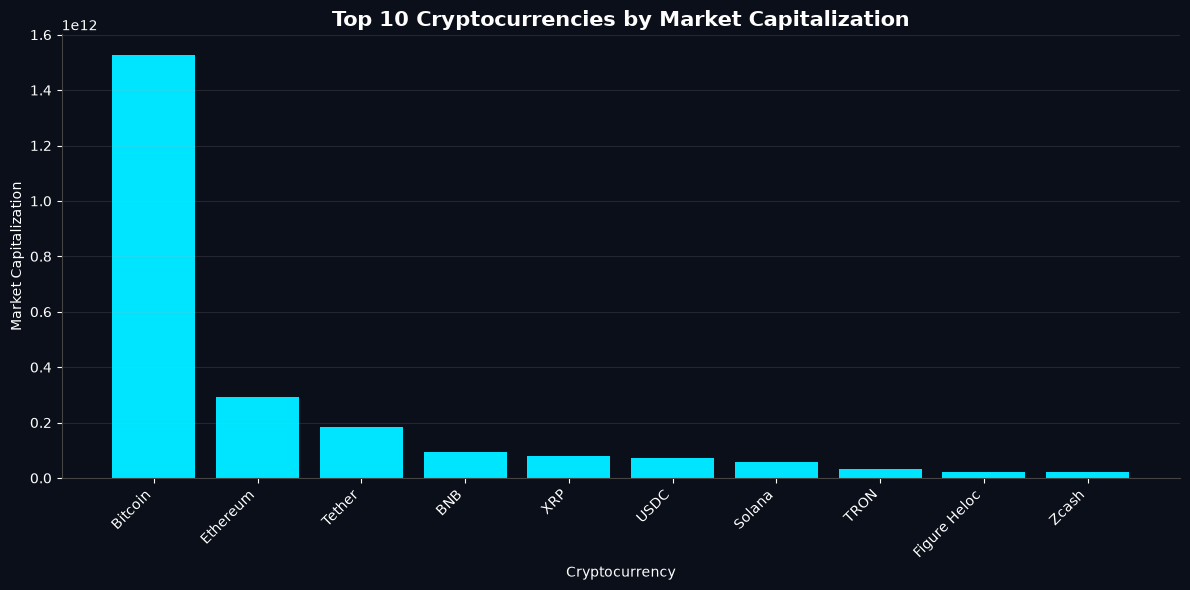

In [154]:
top_10_market_cap = crypto_cleaned.nlargest(10, "market_cap")

plt.figure(figsize=(12, 6), facecolor="#0b0f19")
ax = plt.gca()
ax.set_facecolor("#0b0f19")

bars = ax.bar(
    top_10_market_cap["name"],
    top_10_market_cap["market_cap"],
    color="#00e5ff"
)

plt.xticks(rotation=45, ha="right", color="white")
plt.yticks(color="white")
plt.xlabel("Cryptocurrency", color="white")
plt.ylabel("Market Capitalization", color="white")
plt.title(
    "Top 10 Cryptocurrencies by Market Capitalization",
    color="white",
    fontsize=15,
    fontweight="bold"
)

ax.tick_params(colors="white")
ax.spines["bottom"].set_color("#444444")
ax.spines["left"].set_color("#444444")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.grid(axis="y", alpha=0.15)
plt.tight_layout()

plt.savefig(
    "../reports/figures/top_10_crypto_market_cap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 9.5 Top 10 Cryptocurrency Gainers

This analysis identifies the cryptocurrencies with the highest 24-hour percentage price increases.

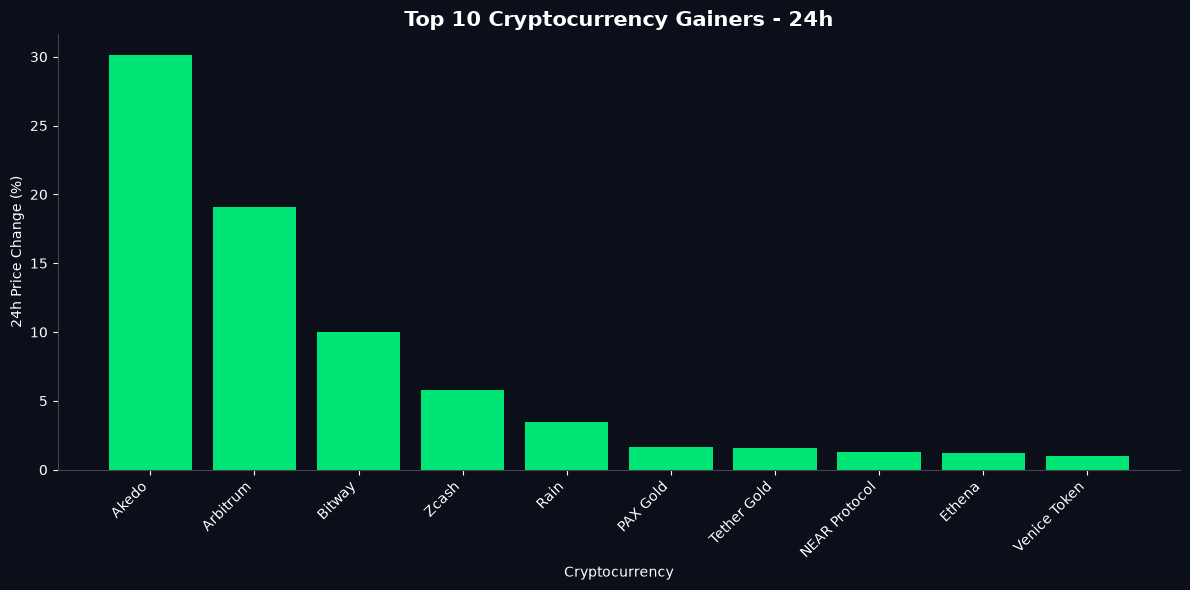

In [173]:
top_gainers = crypto_cleaned.nlargest(
    10, "price_change_percentage_24h"
)
top_gainers.to_csv(
    "../reports/tables/top_10_crypto_gainers.csv",
    index=False
)
plt.figure(figsize=(12, 6), facecolor="#0b0f19")
ax = plt.gca()
ax.set_facecolor("#0b0f19")

ax.bar(
    top_gainers["name"],
    top_gainers["price_change_percentage_24h"],
    color="#00e676"
)

plt.xticks(rotation=45, ha="right", color="white")
plt.yticks(color="white")
plt.xlabel("Cryptocurrency", color="white")
plt.ylabel("24h Price Change (%)", color="white")
plt.title(
    "Top 10 Cryptocurrency Gainers - 24h",
    color="white",
    fontsize=15,
    fontweight="bold"
)

ax.tick_params(colors="white")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_color("#444444")
ax.spines["left"].set_color("#444444")

plt.tight_layout()

plt.savefig(
    "../reports/figures/top_10_crypto_gainers.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 9.6 Top 10 Cryptocurrency Losers

This analysis identifies the cryptocurrencies with the largest 24-hour percentage price decreases.

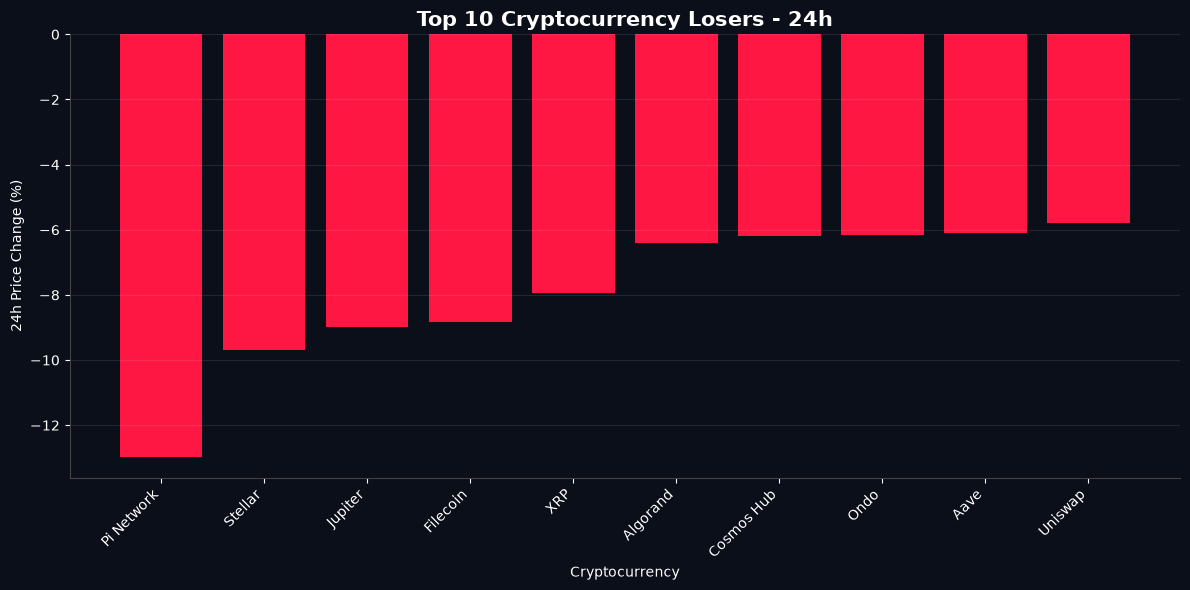

In [172]:
top_losers = crypto_cleaned.nsmallest(
    10, "price_change_percentage_24h"
)
top_losers.to_csv(
    "../reports/tables/top_10_crypto_losers.csv",
    index=False
)
plt.figure(figsize=(12, 6), facecolor="#0b0f19")
ax = plt.gca()
ax.set_facecolor("#0b0f19")

ax.bar(
    top_losers["name"],
    top_losers["price_change_percentage_24h"],
    color="#ff1744"
)

plt.xticks(rotation=45, ha="right", color="white")
plt.yticks(color="white")

plt.xlabel("Cryptocurrency", color="white")
plt.ylabel("24h Price Change (%)", color="white")

plt.title(
    "Top 10 Cryptocurrency Losers - 24h",
    color="white",
    fontsize=15,
    fontweight="bold"
)

ax.tick_params(colors="white")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_color("#444444")
ax.spines["left"].set_color("#444444")

plt.grid(axis="y", alpha=0.15)
plt.savefig(
    "../reports/figures/top_10_crypto_losers.png",
    dpi=300,
    bbox_inches="tight"
)
plt.tight_layout()
plt.show()

## 9.7 Price Change Analysis

This section analyzes the 24-hour price changes of cryptocurrencies in the dataset. The analysis helps identify the overall distribution of price movements and understand whether most cryptocurrencies experienced gains or losses during the 24-hour period.

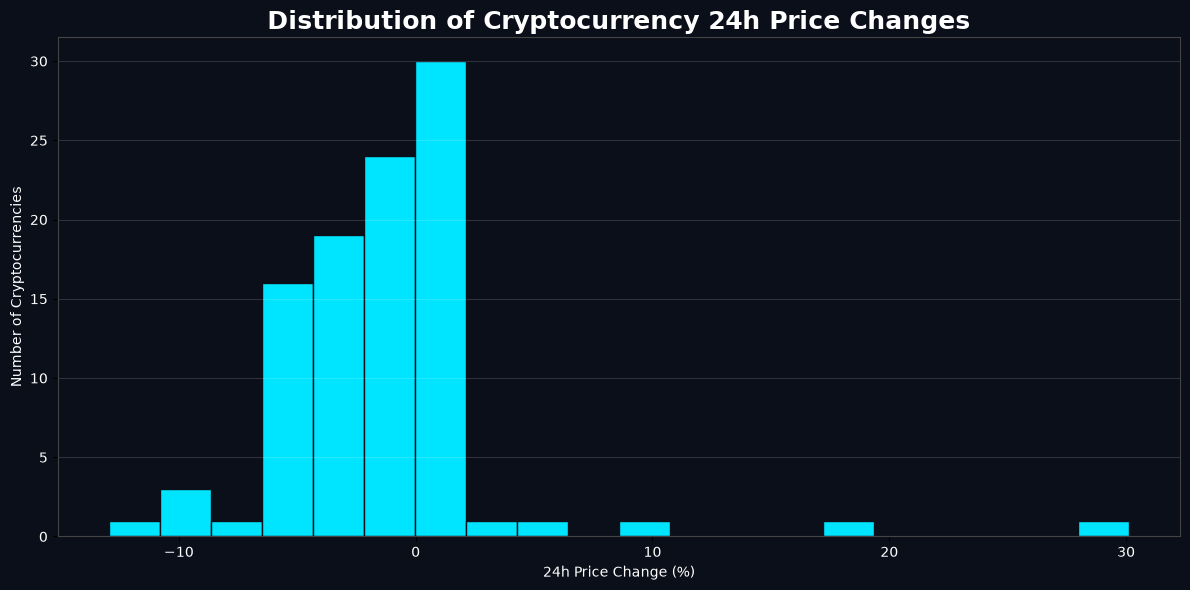

In [174]:
price_change = crypto_cleaned["price_change_percentage_24h"].dropna()

plt.figure(figsize=(12, 6), facecolor="#0b0f19")

ax = plt.gca()
ax.set_facecolor("#0b0f19")

ax.hist(
    price_change,
    bins=20,
    color="#00e5ff",
    edgecolor="#0b0f19"
)

plt.title(
    "Distribution of Cryptocurrency 24h Price Changes",
    fontsize=18,
    fontweight="bold",
    color="white"
)

plt.xlabel(
    "24h Price Change (%)",
    color="white"
)

plt.ylabel(
    "Number of Cryptocurrencies",
    color="white"
)

plt.xticks(color="white")
plt.yticks(color="white")

ax.grid(axis="y", alpha=0.15, color="white")

for spine in ax.spines.values():
    spine.set_color("#444444")

plt.tight_layout()
plt.savefig(
    "../reports/figures/crypto_24h_price_change_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## 9.8 Volatility Analysis

Volatility measures the price variation of a cryptocurrency during the last 24 hours.

The volatility percentage is calculated using the 24-hour high and low prices. 
Higher volatility indicates larger price fluctuations, while lower volatility 
indicates relatively stable price movement.

This analysis identifies the cryptocurrencies that experienced the highest 
24-hour price volatility.

In [158]:
print(crypto_cleaned.columns.tolist())

['id', 'symbol', 'name', 'current_price', 'market_cap', 'market_cap_rank', 'fully_diluted_valuation', 'total_volume', 'high_24h', 'low_24h', 'price_change_24h', 'price_change_percentage_24h', 'market_cap_change_24h', 'market_cap_change_percentage_24h', 'circulating_supply', 'total_supply', 'max_supply', 'ath', 'ath_change_percentage', 'ath_date', 'atl', 'atl_change_percentage', 'atl_date', 'last_updated', 'roi_percentage', 'price_change_status', 'market_cap_category', 'volatility_percentage', 'volatility_category']


In [175]:
top_volatility = (
    crypto_cleaned
    .nlargest(10, "volatility_percentage")
    [["name", "symbol", "volatility_percentage"]]
)

top_volatility
top_volatility.to_csv(
    "../reports/tables/top_10_crypto_volatility.csv",
    index=False
)

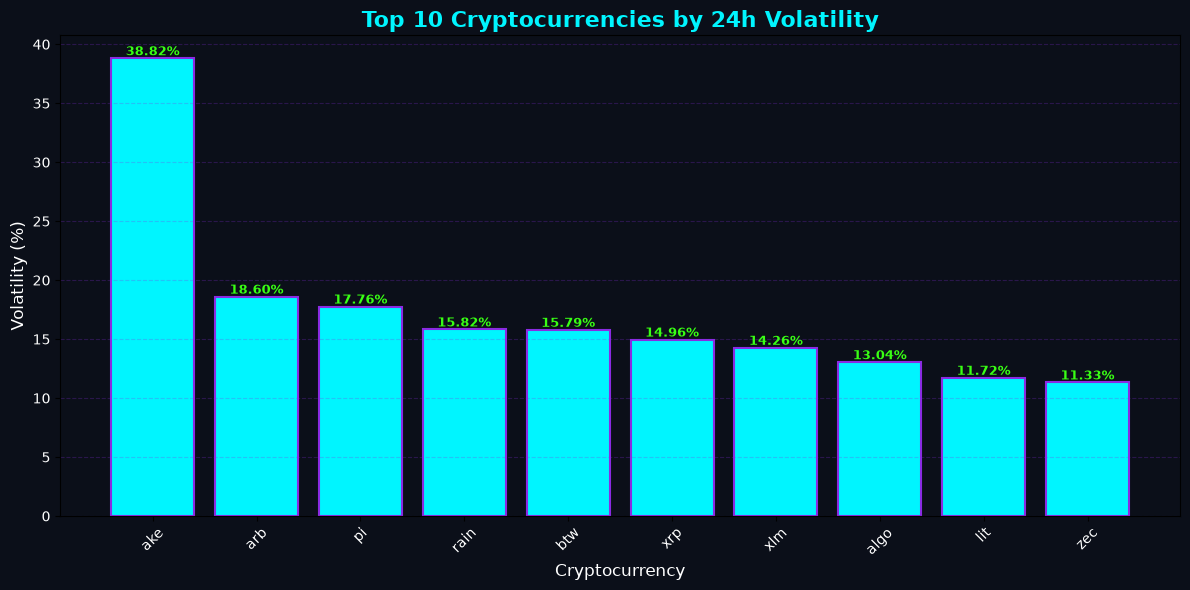

In [176]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

bars = plt.bar(
    top_volatility["symbol"],
    top_volatility["volatility_percentage"],
    color="#00F5FF",
    edgecolor="#8A2BE2",
    linewidth=1.5
)

plt.gca().set_facecolor("#0B0F19")
plt.gcf().patch.set_facecolor("#0B0F19")

plt.title(
    "Top 10 Cryptocurrencies by 24h Volatility",
    fontsize=16,
    fontweight="bold",
    color="#00F5FF"
)

plt.xlabel("Cryptocurrency", color="white", fontsize=12)
plt.ylabel("Volatility (%)", color="white", fontsize=12)

plt.xticks(rotation=45, color="white")
plt.yticks(color="white")

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25,
    color="#8A2BE2"
)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{bar.get_height():.2f}%",
        ha="center",
        va="bottom",
        color="#39FF14",
        fontsize=9,
        fontweight="bold"
    )

plt.tight_layout()
plt.savefig(
    "../reports/figures/top_10_crypto_volatility.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## 9.9 Books Dataset Exploratory Data Analysis

This section explores the cleaned books dataset to understand book prices, ratings, and stock availability.

The analysis uses descriptive statistics and visualizations to identify distributions, patterns, and relationships among the book attributes.

### 9.9.1 Book Price Distribution

This analysis examines the distribution of book prices in the cleaned dataset.

The distribution helps identify the typical price range of books and detect unusually high or low-priced books.

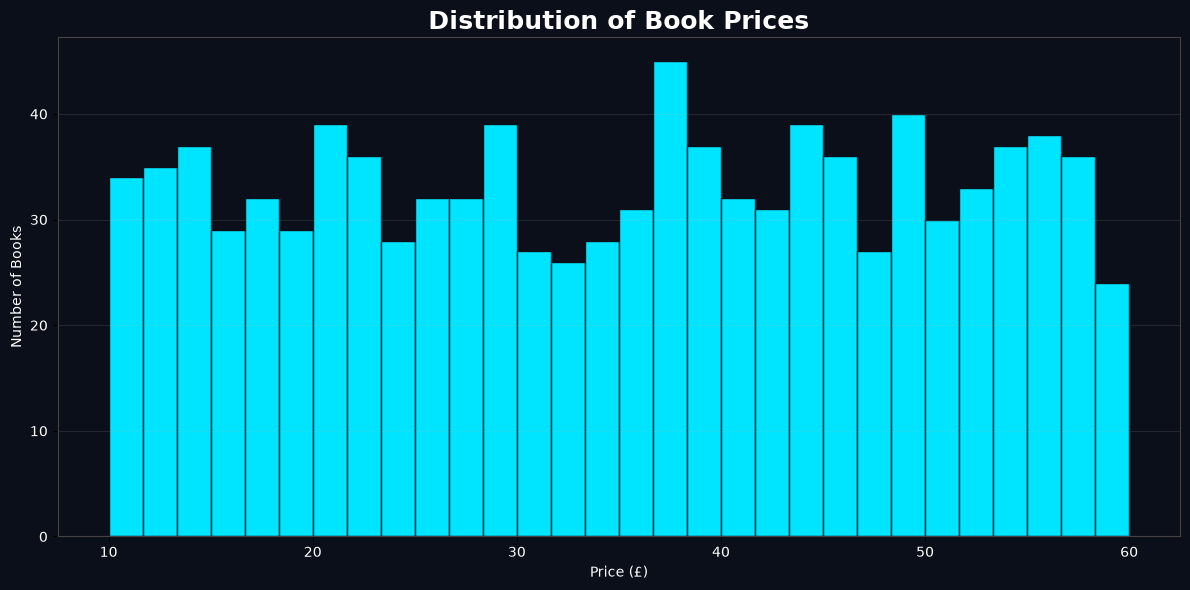

In [177]:
plt.figure(figsize=(12, 6), facecolor="#0b0f19")

ax = plt.gca()
ax.set_facecolor("#0b0f19")

ax.hist(
    books_cleaned["price"],
    bins=30,
    color="#00e5ff",
    edgecolor="#0b0f19"
)

plt.title(
    "Distribution of Book Prices",
    fontsize=18,
    fontweight="bold",
    color="white"
)

plt.xlabel("Price (£)", color="white")
plt.ylabel("Number of Books", color="white")

plt.xticks(color="white")
plt.yticks(color="white")

ax.grid(axis="y", alpha=0.15)

for spine in ax.spines.values():
    spine.set_color("#444444")

plt.tight_layout()
plt.savefig(
    "../reports/figures/book_price_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 9.9.2 Book Rating Analysis

This analysis examines the distribution of ratings across the cleaned books dataset.

The visualization helps understand how books are distributed across different rating levels and identify the most common ratings.

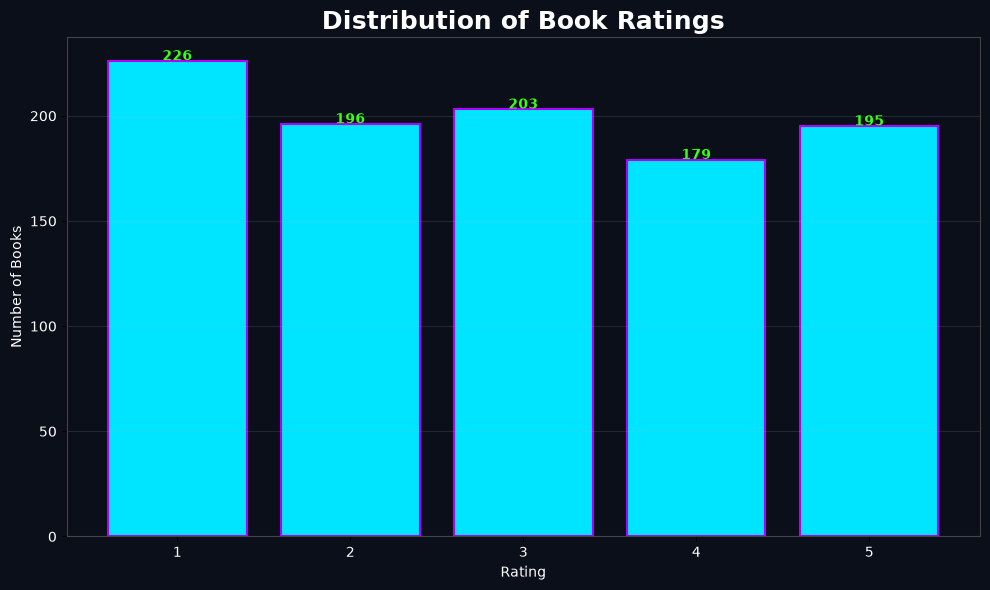

In [178]:
rating_counts = books_cleaned["rating"].value_counts().sort_index()

rating_counts.to_csv(
    "../reports/tables/book_rating_counts.csv",
    header=["count"]
)
plt.figure(figsize=(10, 6), facecolor="#0b0f19")

ax = plt.gca()
ax.set_facecolor("#0b0f19")

bars = ax.bar(
    rating_counts.index.astype(str),
    rating_counts.values,
    color="#00e5ff",
    edgecolor="#b000ff",
    linewidth=1.5
)

plt.title(
    "Distribution of Book Ratings",
    fontsize=18,
    fontweight="bold",
    color="white"
)

plt.xlabel("Rating", color="white")
plt.ylabel("Number of Books", color="white")

plt.xticks(color="white")
plt.yticks(color="white")

ax.grid(axis="y", alpha=0.15)

for spine in ax.spines.values():
    spine.set_color("#444444")

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        int(bar.get_height()),
        ha="center",
        color="#39ff14",
        fontweight="bold"
    )

plt.tight_layout()
plt.savefig(
    "../reports/figures/book_rating_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### 9.9.3 Book Availability Analysis

This analysis examines the availability of books based on their stock status.

The visualization shows how many books fall into Low Stock, Medium Stock, and High Stock categories, helping understand the overall inventory availability.

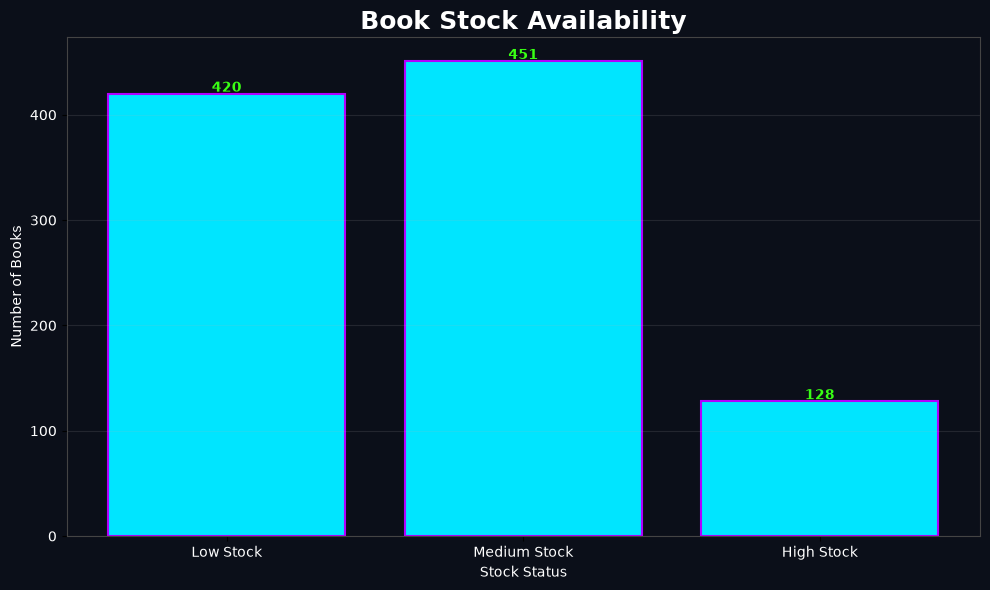

In [181]:
stock_counts = books_cleaned["stock_status"].value_counts().reindex(
    ["Low Stock", "Medium Stock", "High Stock"]
)
stock_counts.to_csv(
    "../reports/tables/book_stock_status_counts.csv",
    header=["count"]
)
plt.figure(figsize=(10, 6), facecolor="#0b0f19")

ax = plt.gca()
ax.set_facecolor("#0b0f19")

bars = ax.bar(
    stock_counts.index,
    stock_counts.values,
    color="#00e5ff",
    edgecolor="#b000ff",
    linewidth=1.5
)

plt.title(
    "Book Stock Availability",
    fontsize=18,
    fontweight="bold",
    color="white"
)

plt.xlabel("Stock Status", color="white")
plt.ylabel("Number of Books", color="white")

plt.xticks(color="white")
plt.yticks(color="white")

ax.grid(axis="y", alpha=0.15)

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2,
        int(bar.get_height()),
        ha="center",
        color="#39ff14",
        fontweight="bold"
    )

for spine in ax.spines.values():
    spine.set_color("#444444")

plt.tight_layout()
plt.savefig(
    "../reports/figures/book_stock_availability.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### 9.9.4 Price vs Rating Analysis

This analysis examines the relationship between book price and rating.

A scatter plot is used to identify whether books with higher ratings tend to have higher or lower prices and to observe the overall relationship between the two variables.

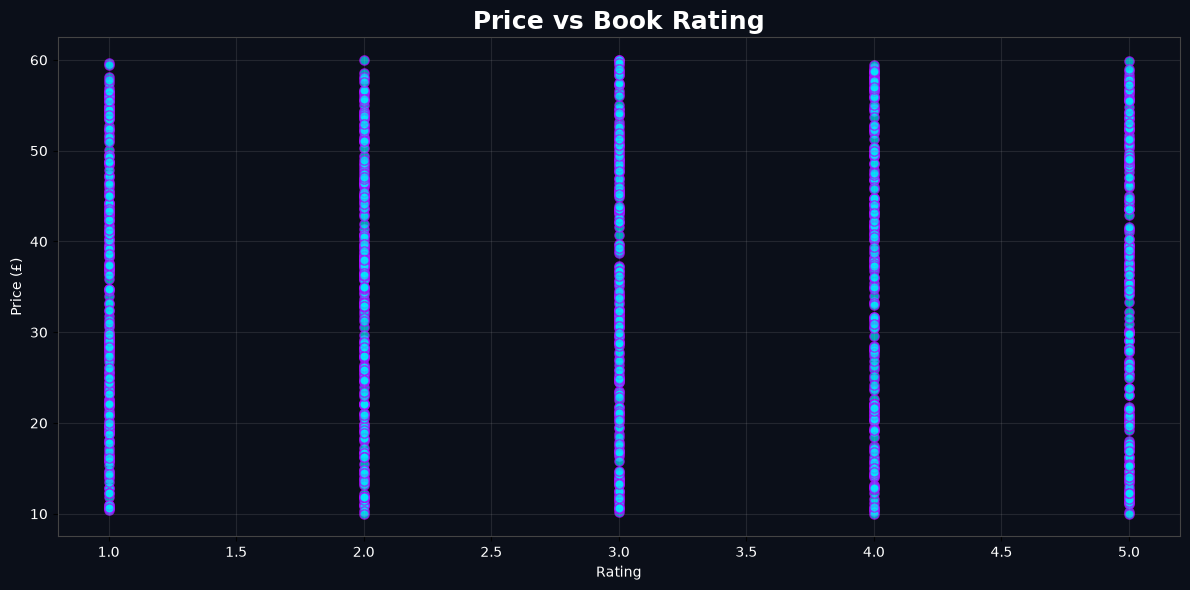

In [182]:
plt.figure(figsize=(12, 6), facecolor="#0b0f19")

ax = plt.gca()
ax.set_facecolor("#0b0f19")

plt.scatter(
    books_cleaned["rating"],
    books_cleaned["price"],
    color="#00e5ff",
    edgecolor="#b000ff",
    alpha=0.7,
    s=45
)

plt.title(
    "Price vs Book Rating",
    fontsize=18,
    fontweight="bold",
    color="white"
)

plt.xlabel("Rating", color="white")
plt.ylabel("Price (£)", color="white")

plt.xticks(color="white")
plt.yticks(color="white")

ax.grid(alpha=0.15)

for spine in ax.spines.values():
    spine.set_color("#444444")

plt.tight_layout()

plt.show()

### 9.9.5 Average Price by Rating

This analysis compares the average price of books across different rating levels.

Grouping books by rating helps identify whether higher-rated books tend to have higher or lower average prices.

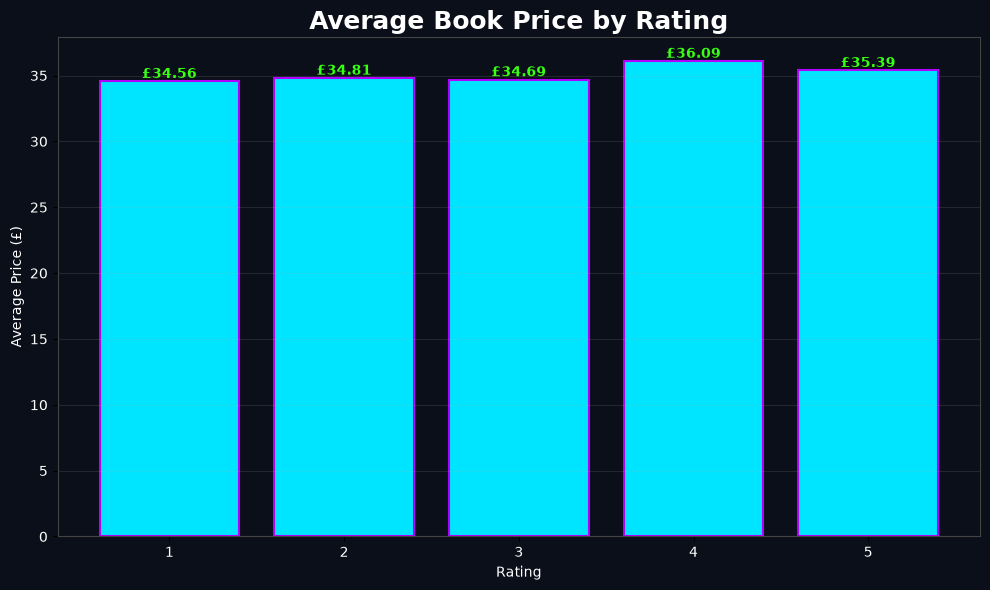

In [165]:
avg_price_by_rating = (
    books_cleaned
    .groupby("rating")["price"]
    .mean()
    .sort_index()
)

plt.figure(figsize=(10, 6), facecolor="#0b0f19")

ax = plt.gca()
ax.set_facecolor("#0b0f19")

bars = plt.bar(
    avg_price_by_rating.index.astype(str),
    avg_price_by_rating.values,
    color="#00e5ff",
    edgecolor="#b000ff",
    linewidth=1.5
)

plt.title(
    "Average Book Price by Rating",
    fontsize=18,
    fontweight="bold",
    color="white"
)

plt.xlabel("Rating", color="white")
plt.ylabel("Average Price (£)", color="white")

plt.xticks(color="white")
plt.yticks(color="white")

ax.grid(axis="y", alpha=0.15)

for bar, value in zip(bars, avg_price_by_rating.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"£{value:.2f}",
        ha="center",
        va="bottom",
        color="#39ff14",
        fontweight="bold"
    )

for spine in ax.spines.values():
    spine.set_color("#444444")

plt.tight_layout()
plt.show()

### 9.9.6 Price vs Rating Correlation

Correlation is used to measure the strength and direction of the relationship between book price and rating.

A correlation value close to 1 indicates a strong positive relationship, while a value close to -1 indicates a strong negative relationship. A value close to 0 indicates a weak or no linear relationship.

In [166]:
price_rating_corr = books_cleaned[["price", "rating"]].corr().loc["price", "rating"]

print(f"Price vs Rating Correlation: {price_rating_corr:.3f}")

Price vs Rating Correlation: 0.028


# 10. Save Cleaned Cryptocurrency Dataset

The final cryptocurrency dataset is exported after completing data cleaning and feature engineering.

The cleaned dataset is stored separately from the raw dataset so that the original collected data remains unchanged.

In [167]:
crypto_raw.to_csv(
    "../data/raw/crypto_raw.csv",
    index=False
)

import os

file_path = "../data/processed/crypto_cleaned.csv"

print("File exists:", os.path.exists(file_path))
print("File path:", file_path)

File exists: True
File path: ../data/processed/crypto_cleaned.csv


In [168]:
crypto_check = pd.read_csv("../data/processed/crypto_cleaned.csv")
print("Saved dataset shape:", crypto_check.shape)
crypto_check.head()

Saved dataset shape: (100, 29)


,id,symbol,name,current_price,market_cap,market_cap_rank,fully_diluted_valuation,total_volume,high_24h,low_24h,...,ath_date,atl,atl_change_percentage,atl_date,last_updated,roi_percentage,price_change_status,market_cap_category,volatility_percentage,volatility_category
0,bitcoin,btc,Bitcoin,79344.000000,1593197145614,1,1593199684347,3.417089e+10,79701.000000,77666.00000,...,2025-10-06 10:57:42+00:00,67.810000,1.169103e+05,2013-07-05 16:00:00+00:00,2026-09-09 12:00:20+00:00,NaN,Gain,Large Cap,2.620194,Medium
1,ethereum,eth,Ethereum,2501.710000,305269538303,2,305269538303,1.216824e+10,2521.510000,2442.98000,...,2025-08-24 11:21:03+00:00,0.432979,5.776907e+05,2015-10-19 16:00:00+00:00,2026-09-09 12:00:20+00:00,4115.035581,Gain,Large Cap,3.214517,Medium
2,tether,usdt,Tether,0.999769,183419773573,3,188885514927,5.284982e+10,0.999995,0.99953,...,2018-07-23 16:00:00+00:00,0.572521,7.462575e+01,2015-03-01 16:00:00+00:00,2026-09-09 12:00:20+00:00,NaN,Gain,Large Cap,0.046522,Low
3,binancecoin,bnb,BNB,750.460000,99922928329,4,99922928697,9.456896e+08,757.360000,742.69000,...,2025-10-13 00:41:24+00:00,0.039818,1.884644e+06,2017-10-18 16:00:00+00:00,2026-09-09 12:00:20+00:00,NaN,Loss,Mid Cap,1.975252,Low
4,ripple,xrp,XRP,1.430000,89555778817,5,142710358135,2.643268e+09,1.450000,1.38000,...,2025-07-17 19:40:53+00:00,0.002686,5.302761e+04,2014-05-21 16:00:00+00:00,2026-09-09 12:00:20+00:00,NaN,Gain,Mid Cap,5.072464,High


# 11. Key Insights & Findings

## Cryptocurrency Insights

- Bitcoin has the highest market capitalization among the cryptocurrencies analyzed, followed by Ethereum and Tether.
- The top 10 cryptocurrencies account for approximately 90.75% of the total market capitalization in the dataset, showing strong concentration among the largest cryptocurrencies.
- Venice Token recorded the highest 24-hour price increase at approximately 46.62%.
- Aerodrome Finance recorded the largest 24-hour price decrease at approximately -6.09%.
- The 24-hour price change analysis shows that most cryptocurrencies experienced relatively smaller movements, while a few cryptocurrencies showed significantly larger changes.
- Volatility varies considerably across cryptocurrencies. Venice Token recorded the highest 24-hour volatility at approximately 55.51%.
- The cryptocurrency dataset contains both gainers and losers, demonstrating variation in short-term market performance.

## Book Dataset Insights

- Book prices range from £10.00 to £59.99, with most books concentrated in the middle price range.
- The rating distribution contains books across all five rating levels, with 1-star books being the most numerous.
- Medium-stock books represent the largest stock category, followed by low-stock books, while high-stock books are comparatively fewer.
- Average book prices are very similar across different rating levels.
- The correlation between book price and rating is 0.028, indicating an almost negligible linear relationship.
- Therefore, a higher-rated book does not necessarily have a higher price in this dataset.

## Overall Findings

The analysis demonstrates how data collected from different sources can be transformed into structured, analysis-ready datasets through data cleaning, feature engineering, exploratory data analysis, and visualization. The cryptocurrency analysis highlights market capitalization, short-term price movements, and volatility, while the book analysis focuses on price, ratings, and stock availability.

# 12. Conclusion

This project developed an end-to-end multi-source data analysis pipeline using Python.

Data was collected from two different sources: the CoinGecko API for cryptocurrency market data and Books to Scrape for book-product data. The raw datasets were inspected, cleaned, validated, transformed, and exported as separate cleaned CSV files.

For the cryptocurrency dataset, the analysis examined market capitalization, 24-hour price changes, price movements, and volatility. Feature engineering was also performed to create price-change status, market-cap categories, and volatility categories.

For the book dataset, price, rating, and availability information were cleaned and transformed. Additional features such as price range, rating group, stock quantity, and stock status were created. Exploratory analysis was then performed using statistical summaries and visualizations.

The analysis showed that cryptocurrency market capitalization is highly concentrated among the largest cryptocurrencies, while short-term price changes and volatility vary considerably across assets. In the book dataset, prices were distributed across a broad range, while the very low correlation between price and rating (0.028) indicated that book rating is not a strong linear predictor of price.

Overall, the project demonstrates a complete data-analysis workflow involving data collection, data cleaning, feature engineering, exploratory data analysis, visualization, insight generation, and cleaned dataset export.